In [1]:
# ---
# jupyter:
#   jupytext:
#     text_representation:
#       extension: .py
#       format_name: percent
#       format_version: '1.3'
#   kernelspec:
#     display_name: Python 3
#     language: python
#     name: python3
# ---

# KL divergence를 코드로 계산하기

카드의 한 줄:

```python
def kl(q, p):
    return (q * (q.clamp_min(1e-12).log() - p.clamp_min(1e-12).log())).sum(-1)
```

이 한 줄이 무엇을 계산하고, 왜 저렇게 생겼고, 실전에서 어디서 틀리는지를 숫자로 확인한다.

다루는 것:

1. 나이브 구현과 수식 $\sum_i q_i(\log q_i - \log p_i)$ 의 1:1 대응
2. **비대칭성** — $D_{KL}(q\|p) \ne D_{KL}(p\|q)$, forward/reverse의 성격 차이
3. **수치 안정성** — 나이브 vs `F.kl_div` vs `torch.distributions.kl_divergence`
4. **$H(q,p) = h(q) + D_{KL}(q\|p)$** 항등식 검증
5. $p$를 균등분포 쪽으로 움직이며 forward/reverse KL 곡선 그리기

In [2]:
import math

import torch
import torch.nn.functional as F
from torch.distributions import Categorical

torch.set_printoptions(precision=4, sci_mode=False)


def _show(fig):
    try:
        from IPython import get_ipython
        if get_ipython() is not None:
            fig.show()
    except ImportError:
        pass

## 1. 나이브 구현 — 수식과 한 글자씩 맞춰보기

$$D_{KL}(q\,\|\,p) = \sum_i q_i \log\frac{q_i}{p_i} = \sum_i q_i\big(\log q_i - \log p_i\big)$$

| 수식 | 코드 |
|---|---|
| $q_i$ | `q` |
| $\log q_i$ | `q.clamp_min(1e-12).log()` |
| $\log p_i$ | `p.clamp_min(1e-12).log()` |
| $\log q_i - \log p_i$ | 괄호 안의 뺄셈 (= $\log(q_i/p_i)$) |
| $\sum_i$ | `.sum(-1)` — 마지막 축(클래스 축)만 합, 배치 축은 남긴다 |

`clamp_min(1e-12)`는 $\log 0 = -\infty$ 를 막는 방어막이다.
**나눗셈 대신 로그 뺄셈**을 쓰는 이유도 같다: $q_i/p_i$ 는 $p_i$ 가 작을 때 바로 `inf`/`nan`으로 터진다.

In [3]:
def entropy(p):
    return -(p * p.clamp_min(1e-12).log()).sum(-1)


def cross_entropy(q, p):
    return -(q * p.clamp_min(1e-12).log()).sum(-1)


def kl(q, p):
    return (q * (q.clamp_min(1e-12).log() - p.clamp_min(1e-12).log())).sum(-1)


q = torch.tensor([0.7, 0.2, 0.1])
p = torch.tensor([0.3, 0.3, 0.4])

term = q * (q.log() - p.log())          # 항별 기여
print("q      =", q)
print("p      =", p)
print("항별    =", term, "  <- q_i (log q_i - log p_i)")
print("합      =", term.sum().item())
print("kl(q,p) =", kl(q, p).item())

q      = tensor([0.7000, 0.2000, 0.1000])
p      = tensor([0.3000, 0.3000, 0.4000])
항별    = tensor([ 0.5931, -0.0811, -0.1386])   <- q_i (log q_i - log p_i)
합      = 0.373386025428772
kl(q,p) = 0.373386025428772


항별 기여는 **음수도 될 수 있다**($p_i > q_i$인 자리). 그런데 총합은 항상 $\ge 0$이다(Gibbs 부등식).
그리고 $q = p$일 때만 정확히 0이다.

In [4]:
print("kl(q, q)      =", kl(q, q).item())          # 자기 자신 -> 0
print("kl(p, p)      =", kl(p, p).item())

# 배치 입력: sum(-1)이 마지막 축만 줄이므로 (B, K) -> (B,)
Q = torch.tensor([[0.7, 0.2, 0.1],
                  [0.1, 0.1, 0.8],
                  [1 / 3, 1 / 3, 1 / 3]])
P = p.expand_as(Q)
print("batch kl shape =", tuple(kl(Q, P).shape), " values =", kl(Q, P))

kl(q, q)      = 0.0
kl(p, p)      = 0.0
batch kl shape = (3,)  values = tensor([0.3734, 0.3348, 0.0095])


## 2. 비대칭성 — $D_{KL}(q\|p) \ne D_{KL}(p\|q)$

KL은 "거리"가 아니다. 인자 순서를 바꾸면 값이 달라진다.
관례상 $D_{KL}(q\|p)$ 에서 **앞자리 $q$ 가 가중치(정답/타깃), 뒷자리 $p$ 가 채점당하는 쪽(모델)** 이다.

In [5]:
a = torch.tensor([0.7, 0.2, 0.1])
b = torch.tensor([0.1, 0.2, 0.7])
print(f"KL(a||b) = {kl(a, b).item():.4f}")
print(f"KL(b||a) = {kl(b, a).item():.4f}   (이 쌍은 대칭이라 우연히 같다)")

a2 = torch.tensor([0.98, 0.01, 0.01])
b2 = torch.tensor([0.34, 0.33, 0.33])
print(f"KL(a2||b2) = {kl(a2, b2).item():.4f}")
print(f"KL(b2||a2) = {kl(b2, a2).item():.4f}   <- 2배 차이")

KL(a||b) = 1.1675
KL(b||a) = 1.1675   (이 쌍은 대칭이라 우연히 같다)
KL(a2||b2) = 0.9675
KL(b2||a2) = 1.9478   <- 2배 차이


### 왜 비대칭인가 — 가중치가 앞자리 분포에서 온다

$\sum_i q_i \log(q_i/p_i)$ 에서 각 항은 $q_i$ 로 가중된다. 그래서:

- $q_i > 0$ 인데 $p_i \approx 0$ → $\log(q_i/p_i)$ 가 거대한데 가중치 $q_i$ 도 크다 → **폭발**
- $q_i \approx 0$ 인데 $p_i$ 가 크다 → 가중치가 0이라 **무시된다**

정리:

| 방향 | 이름 | 성격 | 벌점을 주는 실수 |
|---|---|---|---|
| $D_{KL}(q\|p)$, $q$ 고정 target | **forward / mass-covering** | $p$ 가 $q$의 모든 봉우리를 덮어야 함 | $q$ 가 있는 곳에 $p$ 가 없는 것 |
| $D_{KL}(p\|q)$, 즉 학습 대상이 앞자리 | **reverse / mode-seeking** | $p$ 가 봉우리 **하나**에 몰려도 됨 | $q$ 가 없는 곳에 $p$ 가 있는 것 |

1D 이산 분포로 실증해보자. 봉우리가 두 개인 $q$에 대해 후보 $p$ 두 개를 놓는다.

In [6]:
K = 9
q_bimodal = torch.tensor([0.02, 0.23, 0.02, 0.02, 0.02, 0.02, 0.02, 0.63, 0.02])
p_one_mode = torch.tensor([0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.92, 0.01])  # 큰 봉우리 하나만
p_covering = torch.tensor([0.06, 0.24, 0.08, 0.08, 0.08, 0.08, 0.08, 0.24, 0.06])  # 둘 다 덮음

print(f"{'후보 p':>14s} {'forward KL(q||p)':>18s} {'reverse KL(p||q)':>18s}")
for name, cand in [("one_mode", p_one_mode), ("covering", p_covering)]:
    print(f"{name:>14s} {kl(q_bimodal, cand).item():18.4f} {kl(cand, q_bimodal).item():18.4f}")
print("\nforward가 고르는 것 :", "covering" if kl(q_bimodal, p_covering) < kl(q_bimodal, p_one_mode) else "one_mode")
print("reverse가 고르는 것 :", "covering" if kl(p_covering, q_bimodal) < kl(p_one_mode, q_bimodal) else "one_mode")

          후보 p   forward KL(q||p)   reverse KL(p||q)
      one_mode             0.5797             0.2685
      covering             0.4156             0.4649

forward가 고르는 것 : covering
reverse가 고르는 것 : one_mode


같은 후보 두 개인데 **어느 쪽이 더 좋은지가 방향에 따라 뒤집힌다**.

- forward($q\|p$)는 작은 봉우리를 버린 `one_mode`에 벌점을 준다 → 넓게 덮는 쪽 선택 (mass-covering)
- reverse($p\|q$)는 $q$가 얇은 자리에 확률을 뿌린 `covering`에 벌점을 준다 → 한 봉우리에 몰빵 (mode-seeking)

실무 대응: VAE의 $D_{KL}(q_\phi(z|x)\,\|\,p(z))$ 는 reverse 형태고, 지식증류/DINO의
$-\sum q_{\text{teacher}} \log p_{\text{student}}$ 는 forward 형태다.

## 3. 수치 안정성 — 세 가지 구현 비교

### `F.kl_div` 의 두 가지 함정

```python
F.kl_div(input, target)  #  = Σ target * (log target - input)
```

1. **`input`은 log-probability다** (확률을 그냥 넣으면 조용히 틀린 값이 나온다)
2. **인자 순서가 뒤집혀 있다** — 수식 $D_{KL}(q\|p)$ 의 $q$(타깃)가 두 번째 인자,
   $p$(모델)의 로그가 첫 번째 인자다. 즉 `kl(q, p) == F.kl_div(p.log(), q)`.
3. `reduction`의 기본값은 `'mean'`인데 이건 **원소 개수로 나눈** 평균이라 KL이 아니다.
   분포 하나당 KL을 원하면 `reduction='none'` 후 `.sum(-1)`, 배치 평균이면 `'batchmean'`.
4. `target`도 로그로 주고 싶으면 `log_target=True`.

In [7]:
q3 = torch.tensor([0.7, 0.2, 0.1])
p3 = torch.tensor([0.3, 0.3, 0.4])

naive = kl(q3, p3)
f_none = F.kl_div(p3.log(), q3, reduction="none").sum(-1)                    # 정석
f_batch = F.kl_div(p3.log().unsqueeze(0), q3.unsqueeze(0), reduction="batchmean")
f_logt = F.kl_div(p3.log(), q3.log(), reduction="none", log_target=True).sum(-1)
dist_kl = torch.distributions.kl_divergence(Categorical(probs=q3), Categorical(probs=p3))

print(f"naive kl(q,p)                     = {naive.item():.6f}")
print(f"F.kl_div(p.log(), q, 'none').sum  = {f_none.item():.6f}")
print(f"F.kl_div(..., 'batchmean')        = {f_batch.item():.6f}")
print(f"F.kl_div(p.log(), q.log(), log_target=True) = {f_logt.item():.6f}")
print(f"kl_divergence(Cat(q), Cat(p))     = {dist_kl.item():.6f}")
print("모두 일치?", all(torch.allclose(naive, x, atol=1e-6) for x in [f_none, f_batch, f_logt, dist_kl]))

naive kl(q,p)                     = 0.373386
F.kl_div(p.log(), q, 'none').sum  = 0.373386
F.kl_div(..., 'batchmean')        = 0.373386
F.kl_div(p.log(), q.log(), log_target=True) = 0.373386
kl_divergence(Cat(q), Cat(p))     = 0.373386
모두 일치? True


### 자주 하는 실수 두 개를 실제로 재현

In [8]:
wrong_order = F.kl_div(q3.log(), p3, reduction="none").sum(-1)   # 인자 순서 뒤집음
wrong_prob = F.kl_div(p3, q3, reduction="none").sum(-1)          # log 안 씌우고 확률을 넣음
wrong_mean = F.kl_div(p3.log(), q3)                              # reduction 기본값 'mean'

print(f"정답  kl(q||p)                    = {naive.item():.6f}")
print(f"실수1 인자 순서 뒤집힘 -> kl(p||q) = {wrong_order.item():.6f}  (= {kl(p3, q3).item():.6f})")
print(f"실수2 log 안 씌움 (조용히 틀림)    = {wrong_prob.item():.6f}")
print(f"실수3 reduction='mean' (K로 나눔)  = {wrong_mean.item():.6f}  (= 정답/3 = {naive.item()/3:.6f})")

정답  kl(q||p)                    = 0.373386
실수1 인자 순서 뒤집힘 -> kl(p||q) = 0.421968  (= 0.421968)
실수2 log 안 씌움 (조용히 틀림)    = -1.111819
실수3 reduction='mean' (K로 나눔)  = 0.124462  (= 정답/3 = 0.124462)


/home/sungwoo/miniforge3/envs/trellis/lib/python3.10/site-packages/torch/nn/functional.py:2994: UserWarning: reduction: 'mean' divides the total loss by both the batch size and the support size.'batchmean' divides only by the batch size, and aligns with the KL div math definition.'mean' will be changed to behave the same as 'batchmean' in the next major release.
  warnings.warn(


실수2가 특히 위험하다. **에러도 안 나고 KL이 음수로 나온다** — loss로 쓰면 학습이 발산한다.
"KL이 음수면 `F.kl_div`에 log를 안 씌운 것"이라고 외워두면 된다.

### 극단 케이스: $p_i \to 0$ 인데 $q_i > 0$

이론값은 $+\infty$ 다. 세 구현이 여기서 갈린다.

In [9]:
q4 = torch.tensor([0.5, 0.3, 0.2])

for eps, tag in [(1e-6, "p_i=1e-6"), (1e-20, "p_i=1e-20 (float32 subnormal)"), (0.0, "p_i=0  정확히")]:
    p4 = torch.tensor([1.0 - 2 * eps, eps, eps])
    naive_v = kl(q4, p4).item()
    fkl_v = F.kl_div(p4.log(), q4, reduction="none").sum(-1).item()
    try:
        dist_v = torch.distributions.kl_divergence(Categorical(probs=q4), Categorical(probs=p4)).item()
    except Exception as e:                                       # noqa: BLE001
        dist_v = f"raise {type(e).__name__}"
    print(f"{tag:32s} naive={naive_v:>12.4f}  F.kl_div={fkl_v:>12.4f}  distributions={dist_v}")

p_i=1e-6                         naive=      5.8781  F.kl_div=      5.8781  distributions=5.878103256225586
p_i=1e-20 (float32 subnormal)    naive=     12.7859  F.kl_div=     21.9962  distributions=6.941539764404297
p_i=0  정확히                       naive=     12.7859  F.kl_div=         inf  distributions=inf


**세 구현이 전부 다른 값을 낸다.** 각자 다른 곳에 다른 바닥(floor)을 깔고 있기 때문이다.

| 구현 | 바닥 | $p_i \to 0$ 에서 |
|---|---|---|
| 나이브 `kl` | 명시적 `clamp_min(1e-12)` → 항당 최대 $-\log 10^{-12} \approx 27.6$ | **유한값 12.79에서 포화** |
| `F.kl_div(p.log(), q)` | 없음. `p.log()`를 그대로 믿는다 | $p_i$ 를 따라 계속 커지다 $p_i=0$ 에서 `inf` |
| `kl_divergence(Cat, Cat)` | **숨은 clamp** `probs.clamp(min=finfo.eps)` = $1.19\times10^{-7}$ → 항당 최대 15.94 | 6.94에서 포화, 단 `probs==0`은 특수 처리로 `inf` |

셋 중 `p_i=1e-20`에서 **수학적으로 가장 정확한 건 `F.kl_div`의 21.9962**다.
`torch.distributions`가 6.94를 내는 건 `probs_to_logits`가 float32 eps로 확률을 잘라버리기 때문으로,
세 구현 중 가장 이르게(=$10^{-7}$부터) 값을 왜곡한다. "distributions가 정석이니 제일 정확하겠지"는 틀린 직관이다.

In [10]:
# distributions의 숨은 clamp를 직접 확인
from torch.distributions.utils import probs_to_logits

print("finfo(float32).eps =", torch.finfo(torch.float32).eps)
print("probs_to_logits([1, 1e-20, 1e-20]) =", probs_to_logits(torch.tensor([1.0, 1e-20, 1e-20])))
print("log(1e-20) 진짜 값 =", math.log(1e-20), "  vs  -log(eps) =", -math.log(torch.finfo(torch.float32).eps))

finfo(float32).eps = 1.1920928955078125e-07
probs_to_logits([1, 1e-20, 1e-20]) = tensor([    -0.0000,    -15.9424,    -15.9424])
log(1e-20) 진짜 값 = -46.051701859880914   vs  -log(eps) = 15.942385152878742


$p_i = 0$ 에서는 어느 쪽이 옳은가? **수학적으로는 `inf`가 맞다.** 하지만 학습 루프에서 `inf`는
역전파 시 `nan` 그래디언트로 번져 모델을 통째로 죽인다. 나이브 구현의 `clamp_min(1e-12)`은
"그 항의 기여를 $-\log(10^{-12}) \approx 27.6$ 으로 잘라서 학습이 계속 굴러가게" 하는 실용적 타협이다.
대신 **하한을 얼마로 잡느냐가 곧 KL 값**이 되어버린다.

In [11]:
# clamp 하한이 값에 실제로 얼마나 영향을 주는지
p_zero = torch.tensor([1.0, 0.0, 0.0])
for floor in [1e-6, 1e-12, 1e-20, 1e-30]:
    v = (q4 * (q4.clamp_min(1e-12).log() - p_zero.clamp_min(floor).log())).sum(-1)
    print(f"clamp_min={floor:<8.0e} -> KL = {v.item():8.4f}   (= 0.5*KL항 + (0.3+0.2)*(-log floor) 근사)")
print("\n하한을 낮출수록 값이 커진다 = 사실상 inf를 '얼마나 크게 자를지' 고르는 것")

clamp_min=1e-06    -> KL =   5.8781   (= 0.5*KL항 + (0.3+0.2)*(-log floor) 근사)
clamp_min=1e-12    -> KL =  12.7859   (= 0.5*KL항 + (0.3+0.2)*(-log floor) 근사)
clamp_min=1e-20    -> KL =  21.9962   (= 0.5*KL항 + (0.3+0.2)*(-log floor) 근사)
clamp_min=1e-30    -> KL =  33.5091   (= 0.5*KL항 + (0.3+0.2)*(-log floor) 근사)

하한을 낮출수록 값이 커진다 = 사실상 inf를 '얼마나 크게 자를지' 고르는 것


### 진짜 안정적인 방법: 확률 대신 로짓에서 출발

`softmax` 결과를 다시 `log` 하면 이미 정보가 깎여 있다. 로짓이 있다면 `log_softmax`로
한 번에 가는 것이 가장 안정적이다 (`log_softmax`는 내부에서 max-subtraction을 한다).

In [12]:
logits_p = torch.tensor([12.0, -35.0, -35.0])   # softmax하면 p_2, p_3가 subnormal로 죽는다
logits_q = torch.tensor([1.0, 0.3, 0.0])
qs = F.softmax(logits_q, -1)

p_soft = F.softmax(logits_p, -1)
print("softmax(logits_p)                    =", p_soft)
print("naive kl(q, softmax(p))              =", kl(qs, p_soft).item())
stable = (qs * (F.log_softmax(logits_q, -1) - F.log_softmax(logits_p, -1))).sum(-1)
print("log_softmax 기반 (안정)               =", stable.item())
print("F.kl_div(log_softmax(p), q, 'none')  =",
      F.kl_div(F.log_softmax(logits_p, -1), qs, reduction="none").sum(-1).item())

softmax(logits_p)                    = tensor([    1.0000,     0.0000,     0.0000])
naive kl(q, softmax(p))              = 11.804483413696289
log_softmax 기반 (안정)               = 20.78496742248535
F.kl_div(log_softmax(p), q, 'none')  = 20.784969329833984


나이브 쪽이 **11.80**, 로그공간 쪽이 **20.78**. 참값은 20.78이다.
`softmax`가 $e^{-47} \approx 10^{-21}$ 을 0으로 flush하고, 거기에 `clamp_min(1e-12)`가 다시 얹히면서 값이 거의 절반으로 깎였다.

**정리**: 카드의 나이브 구현은 "확률 두 개가 이미 주어졌을 때"의 교과서적 구현이다.
로짓에 접근할 수 있으면 `log_softmax` 차이를 쓰는 게 언제나 낫다.

## 4. $H(q,p) = h(q) + D_{KL}(q\|p)$ 검증

$$-\sum_i q_i \log p_i \;=\; \underbrace{-\sum_i q_i \log q_i}_{h(q)} \;+\; \underbrace{\sum_i q_i(\log q_i - \log p_i)}_{D_{KL}(q\|p)}$$

우변을 전개하면 $q_i \log q_i$ 항이 상쇄되어 좌변이 된다 — 대수적으로 자명하지만,
**"cross-entropy를 줄이는 길이 두 개"** 라는 DINO 붕괴 논의의 출발점이므로 수치로 확인해 둔다.

In [13]:
K8 = 8
pairs = [
    ("peaked  vs uniform", F.softmax(torch.tensor([4., 1., 0., 0., 0., 0., 0., 0.]), -1), torch.full((K8,), 1 / K8)),
    ("one_hot vs peaked ", F.one_hot(torch.tensor(3), K8).float(), F.softmax(torch.tensor([4., 1., 0., 0., 0., 0., 0., 0.]), -1)),
    ("uniform vs uniform", torch.full((K8,), 1 / K8), torch.full((K8,), 1 / K8)),
    ("one_hot vs one_hot", F.one_hot(torch.tensor(3), K8).float(), F.one_hot(torch.tensor(3), K8).float()),
]
print(f"{'case':20s} {'H(q,p)':>8s} {'h(q)':>8s} {'KL(q||p)':>10s} {'h+KL':>8s}  일치")
for name, qq, pp in pairs:
    H, h, D = cross_entropy(qq, pp), entropy(qq), kl(qq, pp)
    print(f"{name:20s} {H:8.4f} {h:8.4f} {D:10.4f} {h + D:8.4f}  {torch.allclose(H, h + D, atol=1e-5)}")
print(f"\nlog 8 = {math.log(8):.4f}")

case                   H(q,p)     h(q)   KL(q||p)     h+KL  일치
peaked  vs uniform     2.0794   0.6560     1.4235   2.0794  True
one_hot vs peaked      4.1481  -0.0000     4.1481   4.1481  True
uniform vs uniform     2.0794   2.0794     0.0000   2.0794  True
one_hot vs one_hot    -0.0000  -0.0000     0.0000   0.0000  True

log 8 = 2.0794


마지막 두 줄이 DINO 붕괴의 두 얼굴이다:

- `uniform vs uniform`: **KL = 0** 인데 loss는 $\log 8 = 2.08$. student가 teacher를 완벽히 따라갔지만 teacher가 정보를 안 준다 (**균등 붕괴**).
- `one_hot vs one_hot`: **loss = 0**. $h(q)=0$, $KL=0$. 입력과 무관하게 이 한 쌍만 내놓으면 만점 (**원-핫 붕괴**).

즉 cross-entropy를 낮추는 길이 $KL \downarrow$(원하는 것)과 $h(q) \downarrow$(붕괴) 두 개라서
뒷문을 centering/sharpening으로 막아야 한다.

## 5. 시각화 — $p$를 균등분포 쪽으로 밀면서 KL 곡선 보기

$q$를 고정하고

$$p(t) = (1-t)\,q + t\cdot \text{uniform}, \qquad t \in [0, 1]$$

로 $p$를 한 파라미터로 움직인다. $t=0$이면 $p=q$(KL=0), $t=1$이면 $p$=균등.
forward $D_{KL}(q\|p(t))$ 와 reverse $D_{KL}(p(t)\|q)$ 를 겹쳐 그린다.

In [14]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

uni = torch.full((K,), 1 / K)
ts = torch.linspace(0.0, 1.0, 201)
p_path = (1 - ts)[:, None] * q_bimodal[None, :] + ts[:, None] * uni[None, :]   # (201, K)

fwd = kl(q_bimodal.expand_as(p_path), p_path)   # KL(q || p(t))
rev = kl(p_path, q_bimodal.expand_as(p_path))   # KL(p(t) || q)

for t_probe in [0.0, 0.25, 0.5, 0.75, 1.0]:
    i = int(t_probe * (len(ts) - 1))
    print(f"t={ts[i]:.2f}  forward KL(q||p)={fwd[i]:.4f}   reverse KL(p||q)={rev[i]:.4f}")
print(f"\nt=1 forward = h(uniform)-... 확인: KL(q||uni) = {kl(q_bimodal, uni).item():.4f} "
      f"= log K - h(q) = {math.log(K) - entropy(q_bimodal).item():.4f}")

t=0.00  forward KL(q||p)=0.0000   reverse KL(p||q)=0.0000
t=0.25  forward KL(q||p)=0.0706   reverse KL(p||q)=0.0846
t=0.50  forward KL(q||p)=0.2369   reverse KL(p||q)=0.2971
t=0.75  forward KL(q||p)=0.5107   reverse KL(p||q)=0.6178
t=1.00  forward KL(q||p)=1.0204   reverse KL(p||q)=1.0601

t=1 forward = h(uniform)-... 확인: KL(q||uni) = 1.0204 = log K - h(q) = 1.0204


두 곡선 모두 $t=0$에서 0으로 시작해 단조 증가하지만 **높이가 다르다** — reverse가 전 구간에서 위에 있다.
그리고 $t=1$의 forward 값은 $\log K - h(q)$ 와 정확히 일치한다:
$D_{KL}(q\|\text{uniform}) = \sum q_i\log q_i + \log K = \log K - h(q)$.
reverse에는 이런 닫힌 형태가 없다. 같은 경로를 같은 두 분포로 재는데도 값이 다르다는 것,
이게 "KL은 거리가 아니다"의 그림 버전이다.

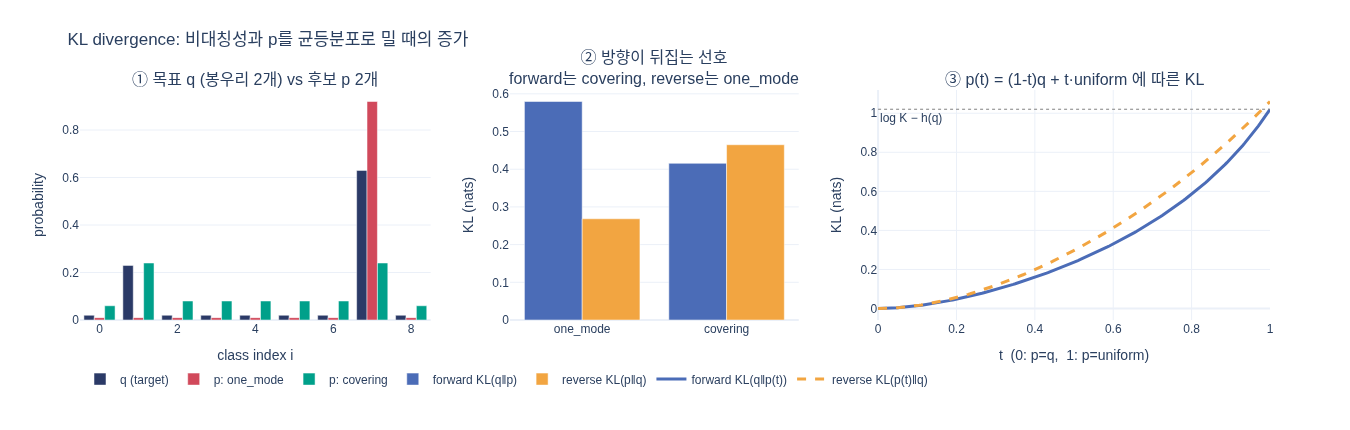

saved: /home/sungwoo/projects/swcho/dino/fm/entropy/.fm/hints/48aa8128-05c6-4537-b94c-0be5d4863e80/expy.png


In [15]:
idx = torch.arange(K).numpy()
fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=(
        "① 목표 q (봉우리 2개) vs 후보 p 2개",
        "② 방향이 뒤집는 선호<br>forward는 covering, reverse는 one_mode",
        "③ p(t) = (1-t)q + t·uniform 에 따른 KL",
    ),
    column_widths=[0.34, 0.28, 0.38],
)

# ① 분포 막대
fig.add_bar(x=idx, y=q_bimodal.numpy(), name="q (target)", marker_color="#2b3a67", row=1, col=1)
fig.add_bar(x=idx, y=p_one_mode.numpy(), name="p: one_mode", marker_color="#d1495b", row=1, col=1)
fig.add_bar(x=idx, y=p_covering.numpy(), name="p: covering", marker_color="#00a08a", row=1, col=1)

# ② forward/reverse가 두 후보에 매기는 점수
fig.add_bar(x=["one_mode", "covering"],
            y=[kl(q_bimodal, p_one_mode).item(), kl(q_bimodal, p_covering).item()],
            name="forward KL(q‖p)", marker_color="#4b6cb7", row=1, col=2)
fig.add_bar(x=["one_mode", "covering"],
            y=[kl(p_one_mode, q_bimodal).item(), kl(p_covering, q_bimodal).item()],
            name="reverse KL(p‖q)", marker_color="#f2a541", row=1, col=2)

# ③ KL 곡선
fig.add_scatter(x=ts.numpy(), y=fwd.numpy(), mode="lines", name="forward KL(q‖p(t))",
                line=dict(color="#4b6cb7", width=3), row=1, col=3)
fig.add_scatter(x=ts.numpy(), y=rev.numpy(), mode="lines", name="reverse KL(p(t)‖q)",
                line=dict(color="#f2a541", width=3, dash="dash"), row=1, col=3)
fig.add_hline(y=math.log(K) - entropy(q_bimodal).item(), line=dict(color="gray", width=1, dash="dot"),
              annotation_text="log K − h(q)", annotation_position="bottom left", row=1, col=3)

fig.update_xaxes(title_text="class index i", row=1, col=1)
fig.update_yaxes(title_text="probability", row=1, col=1)
fig.update_yaxes(title_text="KL (nats)", row=1, col=2)
fig.update_xaxes(title_text="t  (0: p=q,  1: p=uniform)", row=1, col=3)
fig.update_yaxes(title_text="KL (nats)", row=1, col=3)
fig.update_layout(
    title="KL divergence: 비대칭성과 p를 균등분포로 밀 때의 증가",
    height=430, width=1350, barmode="group", template="plotly_white",
    legend=dict(orientation="h", yanchor="bottom", y=-0.32, x=0),
    margin=dict(t=90, b=110),
)
_show(fig)

import os
_png = os.path.join(os.path.dirname(os.path.abspath(__file__)) if "__file__" in globals() else ".", "expy.png")
fig.write_image(_png, scale=2)
print("saved:", _png)

## 정리

```python
def kl(q, p):
    return (q * (q.clamp_min(1e-12).log() - p.clamp_min(1e-12).log())).sum(-1)
```

| 포인트 | 내용 |
|---|---|
| 수식 | $\sum_i q_i(\log q_i - \log p_i)$, 나눗셈 대신 **로그 뺄셈** |
| `clamp_min(1e-12)` | $\log 0 = -\infty$ 방어. $p_i = 0$일 때 `inf` 대신 유한값(≈27.6/항)으로 자른다 |
| `.sum(-1)` | 클래스 축만 합 → 배치 축 유지 |
| 비대칭 | $D_{KL}(q\|p) \ne D_{KL}(p\|q)$. **앞자리가 가중치**, forward=mass-covering / reverse=mode-seeking |
| `F.kl_div` | `F.kl_div(p.log(), q)` — **로그 입력 + 순서 반대**. `reduction='batchmean'`(또는 `'none'`+`sum(-1)`). log 안 씌우면 조용히 음수 |
| `kl_divergence(Cat(q), Cat(p))` | 인자 순서는 수식과 같지만 `probs`를 `finfo.eps`($1.19\times10^{-7}$)로 **몰래 clamp**, $p_i=0$은 `inf` |
| 가장 안정적 | 로짓이 있으면 `(q * (log_softmax(zq) - log_softmax(zp))).sum(-1)` |
| 항등식 | $H(q,p) = h(q) + D_{KL}(q\|p)$ — DINO 붕괴가 $h(q)\downarrow$ 뒷문으로 들어오는 이유 |